In [27]:
import pandas as pd

df = pd.read_csv("/content/Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [28]:
df.shape


(200, 5)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


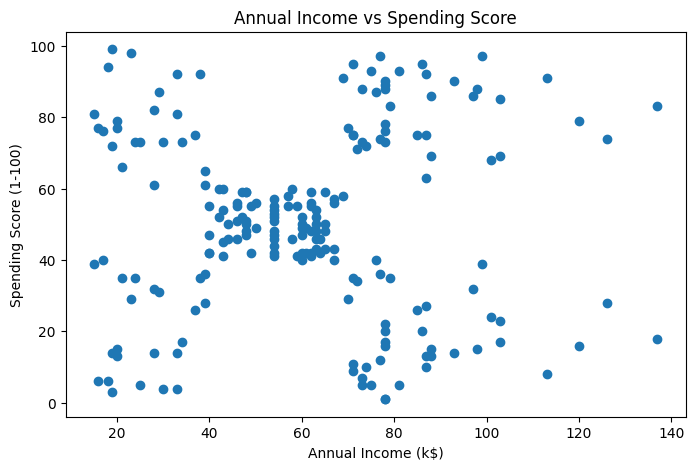

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df.iloc[:, 3],
    df.iloc[:, 4]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.show()

In [8]:
print(df.columns.tolist())

['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [10]:
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [11]:
X.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [13]:
X_scaled.mean(axis=0)

array([-1.02140518e-16, -2.13162821e-16, -1.46549439e-16])

In [14]:
X_scaled.std(axis=0)

array([1., 1., 1.])

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

clusters[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0],
      dtype=int32)

In [16]:
import numpy as np

np.bincount(clusters)

array([68, 41, 91])

In [17]:
np.unique(clusters, return_counts=True)


(array([0, 1, 2], dtype=int32), array([68, 41, 91]))

In [18]:
kmeans.cluster_centers_

array([[-0.93381128, -0.67979753,  0.1338202 ],
       [-0.43033758,  1.02223317,  1.15593564],
       [ 0.8916814 ,  0.04741398, -0.62080368]])

In [19]:
kmeans.cluster_centers_

array([[-0.93381128, -0.67979753,  0.1338202 ],
       [-0.43033758,  1.02223317,  1.15593564],
       [ 0.8916814 ,  0.04741398, -0.62080368]])

In [20]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_original

array([[25.83823529, 42.75      , 53.64705882],
       [32.85365854, 87.34146341, 79.97560976],
       [51.27472527, 61.8021978 , 34.20879121]])

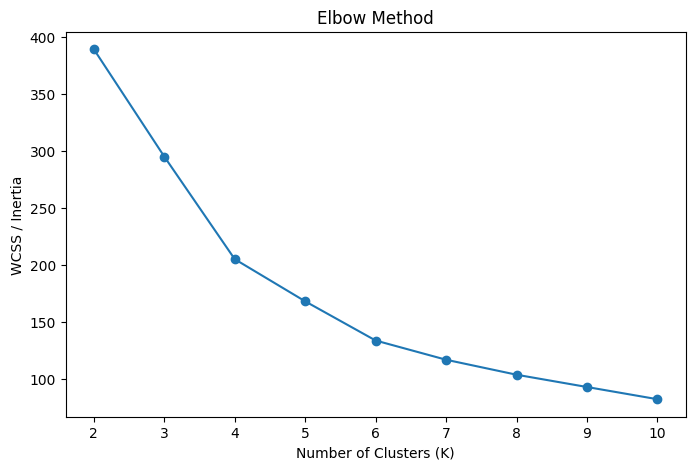

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 11):
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans_test.fit(X_scaled)

    wcss.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

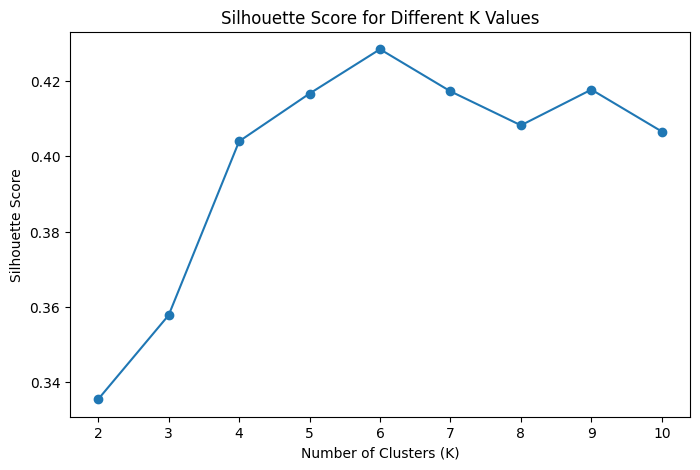

In [22]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans_test.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)

    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

In [23]:
final_kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

final_clusters = final_kmeans.fit_predict(X_scaled)

final_clusters[:20]

array([4, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4],
      dtype=int32)

In [24]:
np.bincount(final_clusters)

array([45, 39, 33, 39, 23, 21])

In [25]:
final_centroids = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)

final_centroids

array([[56.33333333, 54.26666667, 49.06666667],
       [26.79487179, 57.1025641 , 48.12820513],
       [41.93939394, 88.93939394, 16.96969697],
       [32.69230769, 86.53846154, 82.12820513],
       [25.        , 25.26086957, 77.60869565],
       [45.52380952, 26.28571429, 19.38095238]])

In [26]:
centroid_df = pd.DataFrame(
    final_centroids,
    columns=[
        "Age",
        "Annual Income (k$)",
        "Spending Score"
    ]
)

centroid_df.index.name = "Cluster"

centroid_df

,Age,Annual Income (k$),Spending Score
Cluster,,,
0,56.333333,54.266667,49.066667
1,26.794872,57.102564,48.128205
2,41.939394,88.939394,16.969697
3,32.692308,86.538462,82.128205
4,25.000000,25.260870,77.608696
5,45.523810,26.285714,19.380952


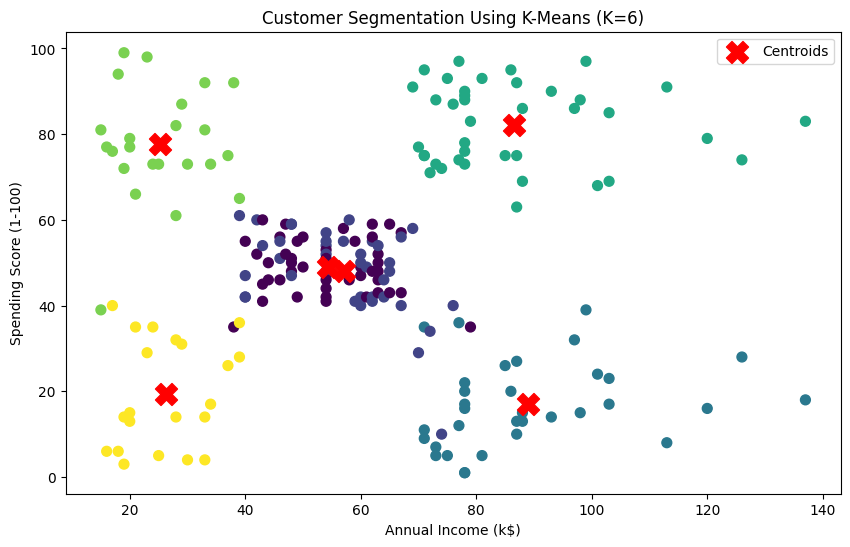

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=final_clusters,
    s=50,
    cmap="viridis"
)

plt.scatter(
    final_centroids[:, 1],
    final_centroids[:, 2],
    s=250,
    c="red",
    marker="X",
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation Using K-Means (K=6)")
plt.legend()

plt.show()

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[-0.61572002, -1.76348088],
       [-1.66579271, -1.82074695],
       [ 0.33786191, -1.67479894],
       [-1.45657325, -1.77242992],
       [-0.03846521, -1.66274012]])

In [32]:
X_pca.shape

(200, 2)

In [33]:
pca.explained_variance_ratio_

array([0.44266167, 0.33308378])

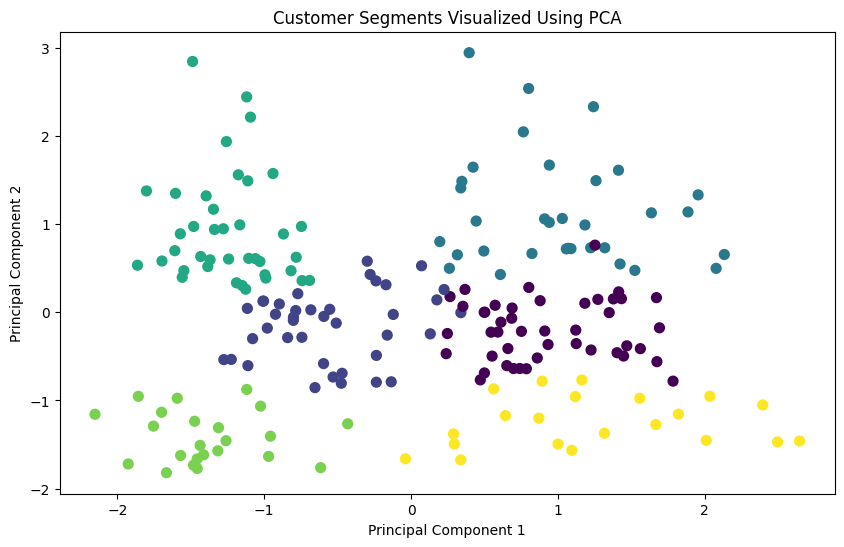

In [34]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_clusters,
    s=50,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments Visualized Using PCA")

plt.show()

In [35]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(
    X_scaled,
    final_clusters
)

final_silhouette

np.float64(0.4284167762892593)

In [36]:
segment_summary = df.groupby(final_clusters).agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
})

segment_summary["Customer Count"] = df.groupby(final_clusters).size()

segment_summary.index.name = "Cluster"

segment_summary

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,56.333333,54.266667,49.066667,45
1,26.794872,57.102564,48.128205,39
2,41.939394,88.939394,16.969697,33
3,32.692308,86.538462,82.128205,39
4,25.000000,25.260870,77.608696,23
5,45.523810,26.285714,19.380952,21


In [37]:
import joblib

joblib.dump(final_kmeans, "customer_segmentation_model.pkl")
joblib.dump(scaler, "customer_segmentation_scaler.pkl")

['customer_segmentation_scaler.pkl']

In [38]:
import os

print(os.path.exists("customer_segmentation_model.pkl"))
print(os.path.exists("customer_segmentation_scaler.pkl"))

True
True


In [39]:
new_customer = [[30, 90, 85]]

In [40]:
new_customer_scaled = scaler.transform(new_customer)

new_customer_scaled

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.6351352 ,  1.12370799,  1.35099031]])

In [41]:
predicted_cluster = final_kmeans.predict(new_customer_scaled)

predicted_cluster

array([3], dtype=int32)